# NBA Predictive Analytics Project (2024-25 Season)

### Ashley Mann | August 2026

Data: https://www.kaggle.com/datasets/eduardopalmieri/nba-player-stats-season-2425

***

## Background & Context

For this project, we'll be using the 2024-2025 NBA Player Stats dataset from Kaggle (link above). The dataset contains 28,254 game-level observations across all NBA teams, with variables describing player performance, playing time, and game context.

The goal is to understand and quantify the relationship between minutes played and points scored. While many variables in the dataset could theoretically be predicted, the focus here is on the fundamental relationship: given a player's minutes on the court, how many points will they score? This EDA establishes that foundational relationship before moving to formal regression analysis and diagnostics.

<span style="color:#E2725B">

### Research Question

Given the number of minutes an athlete plays, how many points will they score?

</span>

### Data

28,254 game-level player observations from Kaggle's 2024-25 NBA season dataset.

### Model

Simple linear regression: PTS ~ MinPlay (predict total points scored from minutes played).

### Data Dictionary / Column Descriptions

| Column | Description |
|--------|-------------|
| Player | Name of the player. |
| Tm | Abbreviation of the player's team. |
| Opp | Abbreviation of the opposing team. |
| Result | Result of the game for the player's team. |
| MP | Minutes played, represented as a float (e.g., `23.5` = 23 minutes and 30 seconds). |
| FG | Field goals made. |
| FGA | Field goal attempts. |
| FG% | Field goal percentage. |
| 3P | 3-point field goals made. |
| 3PA | 3-point field goal attempts. |
| 3P% | 3-point shooting percentage. |
| FT | Free throws made. |
| FTA | Free throw attempts. |
| FT% | Free throw percentage. |
| ORB | Offensive rebounds. |
| DRB | Defensive rebounds. |
| TRB | Total rebounds. |
| AST | Assists. |
| STL | Steals. |
| BLK | Blocks. |
| TOV | Turnovers. |
| PF | Personal fouls. |
| PTS | Total points scored. |
| +/- | Plus/minus, the point differential when the player is on court. |
| GmSc | Game Score, a metric summarizing player performance for the game. |
| Date | Date of the game in `YYYY-MM-DD` format. |

***

## Project Outline

#### 1. Exploratory Data Analysis (EDA)
- Examine data structure and shape
- Check for missing values and data types
- Visualize distributions of key variables (PTS, MP)
- Look for outliers and anomalies
- Basic summary statistics

#### 2. Data Preparation
- Handle missing values
- Remove or flag problematic rows
- Ensure variables are in correct format for modeling

#### 3. Linear Regression: Points from Minutes Played
- Fit OLS model: `PTS ~ MP`
- Extract and interpret coefficients
- Examine model summary (R-squared, F-statistic, p-values)

#### 4. Model Diagnostics & Assumptions
- Check normality of residuals (Jarque-Bera test, Q-Q plot)
- Examine residual plots
- Assess homoscedasticity
- Identify any violations of assumptions

#### 5. Inference & Interpretation
- Confidence intervals on coefficient estimates
- P-values and statistical significance
- Practical interpretation of results

#### 6. Predictions & Visualization
- Generate predictions across a range of MP values
- Calculate confidence intervals and prediction intervals
- Create visualization grid showing:
  - Actual data points (scatter)
  - Predicted line (regression line)
  - Confidence interval ribbon
  - Uncertainty bands

#### 7. Repeat for Additional Outcomes (Optional)
- Build separate models for: FG, 3P, FT, AST from MP
- Apply same workflow to each

#### 8. Summary & Conclusions
- Compare model results across all outcomes
- Discuss findings and patterns

***

<span style="color:#17A697">

## 0. Imports

</span>

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [40]:
df = pd.read_csv('/Users/AMann/Desktop/Coding/NBA Prediction/nba_dailyleaders_full_24_25.csv')
df.head()

,Player,Tm,Unnamed: 3,Opp,Result,MP,FG,FGA,FG%,3P,...,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc,Date
0,Jayson Tatum,BOS,NaN,NYK,W,30:18,14,18,0.778,8,...,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,Anthony Davis,LAL,NaN,MIN,W,37:35,11,23,0.478,1,...,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,Derrick White,BOS,NaN,NYK,W,26:38,8,13,0.615,6,...,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,Jrue Holiday,BOS,NaN,NYK,W,30:31,7,9,0.778,4,...,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,Miles McBride,NYK,@,BOS,L,25:51,8,10,0.800,4,...,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22


In [41]:
df.iloc[:10, :14]

,Player,Tm,Unnamed: 3,Opp,Result,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA
0,Jayson Tatum,BOS,NaN,NYK,W,30:18,14,18,0.778,8,11,0.727,1,2
1,Anthony Davis,LAL,NaN,MIN,W,37:35,11,23,0.478,1,3,0.333,13,15
2,Derrick White,BOS,NaN,NYK,W,26:38,8,13,0.615,6,10,0.600,2,2
3,Jrue Holiday,BOS,NaN,NYK,W,30:31,7,9,0.778,4,6,0.667,0,0
4,Miles McBride,NYK,@,BOS,L,25:51,8,10,0.800,4,5,0.800,2,3
5,Rui Hachimura,LAL,NaN,MIN,W,35:05,7,14,0.500,1,4,0.250,3,4
6,Jaylen Brown,BOS,NaN,NYK,W,29:54,7,18,0.389,5,9,0.556,4,4
7,Rudy Gobert,MIN,@,LAL,L,35:20,5,8,0.625,0,0,NaN,3,4
8,Julius Randle,MIN,@,LAL,L,34:19,5,10,0.500,1,3,0.333,5,7
9,Al Horford,BOS,NaN,NYK,W,26:05,4,7,0.571,3,5,0.600,0,0


In [42]:
df.iloc[:10, 13:]

,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc,Date
0,2,0.500,0,4,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,15,0.867,3,13,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,2,1.000,0,3,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,0,NaN,2,2,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,3,0.667,0,0,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22
5,4,0.750,3,2,5,1,2,1,0,2,18,19.0,15.9,2024-10-22
6,4,1.000,2,5,7,1,1,0,1,3,23,23.0,15.6,2024-10-22
7,4,0.750,3,11,14,2,0,1,1,4,13,-10.0,13.9,2024-10-22
8,7,0.714,3,6,9,4,0,0,2,3,16,2.0,13.7,2024-10-22
9,0,NaN,0,3,3,5,1,1,0,2,11,19.0,13.0,2024-10-22


***

<span style="color:#17A697">

## 1. Exploratory Data Analysis

- Examine data structure and shape
- Check for missing values and data types
- Visualize distributions of key variables (PTS, MP)
- Look for outliers and anomalies
- Basic summary statistics

</span>

<span style="color:#17A697">

#### 1A. Examine data structure and shape

- How many rows and columns are in each data set?
- What are the names and data types for each column?
- How many unique values are there for each column?

</span>

In [43]:
df.shape

(28265, 27)

In [44]:
df.nunique()

Player         569
Tm              30
Unnamed: 3       1
Opp             30
Result           2
MP            2700
FG              23
FGA             40
FG%            200
3P              12
3PA             21
3P%             74
FT              22
FTA             25
FT%             73
ORB             14
DRB             22
TRB             27
AST             23
STL              9
BLK             11
TOV             12
PF               7
PTS             60
+/-             98
GmSc           489
Date           214
dtype: int64

In [45]:
df.columns

Index(['Player', 'Tm', 'Unnamed: 3', 'Opp', 'Result', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', '+/-', 'GmSc', 'Date'],
      dtype='str')

<span style="color:#17A697">

#### 1B. Check for missing values and data types

</span>

In [46]:
df.isna().sum()

Player            0
Tm                0
Unnamed: 3    14208
Opp               0
Result            0
MP                0
FG                0
FGA               0
FG%            1643
3P                0
3PA               0
3P%            5817
FT                0
FTA               0
FT%           12900
ORB               0
DRB               0
TRB               0
AST               0
STL               0
BLK               0
TOV               0
PF                0
PTS               0
+/-              18
GmSc              0
Date              0
dtype: int64

In [64]:
df.dtypes

Player            str
Tm                str
Unnamed: 3        str
Opp               str
Result            str
MP                str
FG              int64
FGA             int64
FG%           float64
3P              int64
3PA             int64
3P%           float64
FT              int64
FTA             int64
FT%           float64
ORB             int64
DRB             int64
TRB             int64
AST             int64
STL             int64
BLK             int64
TOV             int64
PF              int64
PTS             int64
+/-           float64
GmSc          float64
Date              str
dtype: object

In [74]:
drop = df.drop(columns=['Unnamed: 3', '+/-'])
drop.head()

,Player,Tm,Opp,Result,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Date
0,Jayson Tatum,BOS,NYK,W,30:18,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37:35,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26:38,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30:31,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25:51,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22


In [75]:
new_df = drop.rename(columns = {'Tm': 'Team', 'MP': 'MinPlay', 'GmSc': 'GameScore', 'PTS': 'Points'})
new_df.columns

Index(['Player', 'Team', 'Opp', 'Result', 'MinPlay', 'FG', 'FGA', 'FG%', '3P',
       '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'Points', 'GameScore', 'Date'],
      dtype='str')

<span style="color:#17A697">

#### 1C. Visualize distributions of key variables

- PTS
- MinPlay

</span>

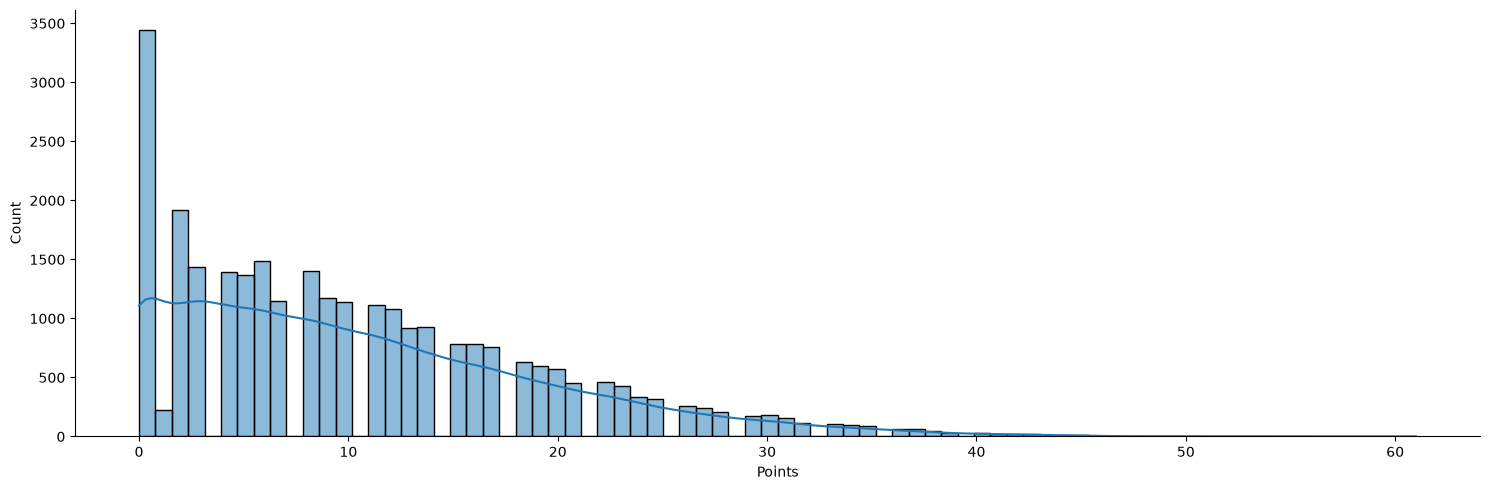

In [76]:
sns.displot(data = new_df, x = 'Points', kind = 'hist', kde = True, aspect = 3)
plt.show()

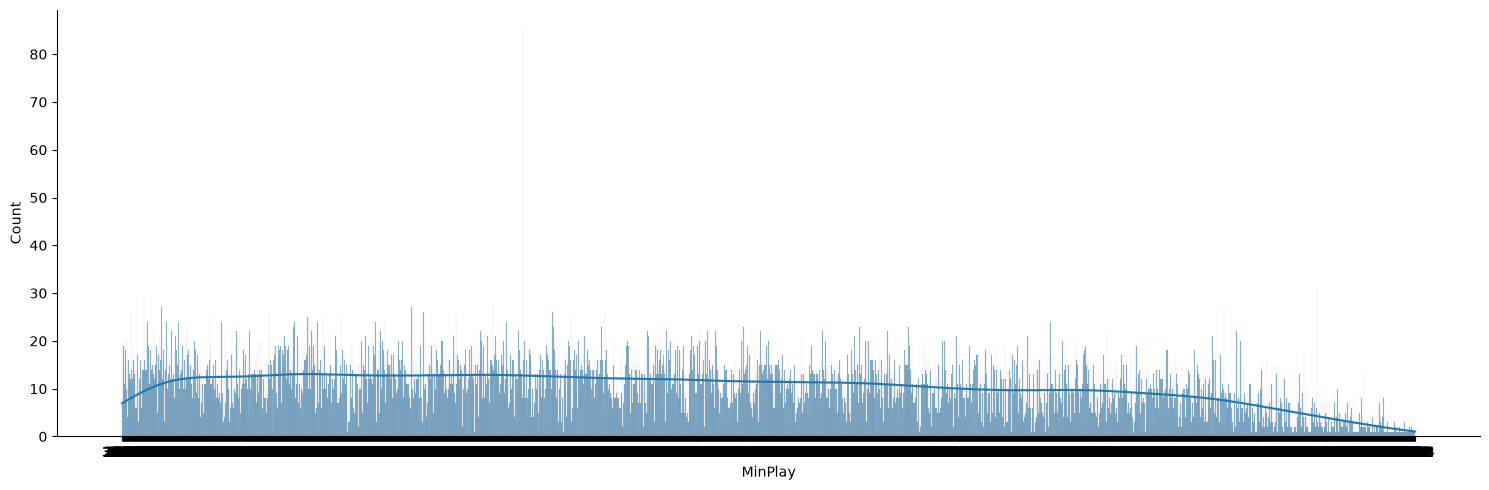

In [80]:
sns.displot(data = new_df, x = 'MinPlay', kind = 'hist', kde = True, aspect = 3)
plt.show()

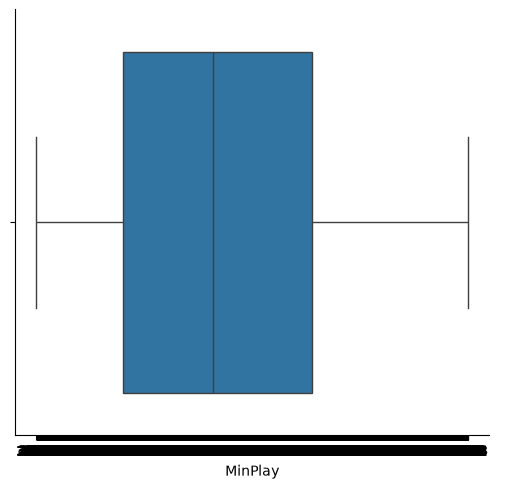

In [81]:
sns.catplot(data = new_df, x = 'MinPlay', kind = 'box')
plt.show()

In [82]:
new_df['MinPlay'].isna().sum()

np.int64(0)

In [83]:
new_df['MinPlay'] = pd.to_numeric(stats_df['MinPlay'], errors='coerce')
sns.kdeplot(data = new_df, x = 'MinPlay', fill = True)
plt.show()

KeyError: 'MinPlay'

In [84]:
df['MP'].head(10)

0    30:18
1    37:35
2    26:38
3    30:31
4    25:51
5    35:05
6    29:54
7    35:20
8    34:19
9    26:05
Name: MP, dtype: str

In [85]:
new_df['MinPlay'].head(10)

0    30:18
1    37:35
2    26:38
3    30:31
4    25:51
5    35:05
6    29:54
7    35:20
8    34:19
9    26:05
Name: MinPlay, dtype: str

In [ ]:
stats_df.head(10)

,Player,Team,Opp,Result,MinPlay,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,Points,GameScore,Date
0,Jayson Tatum,BOS,NYK,W,NaN,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,NaN,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,NaN,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,NaN,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,NaN,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22
5,Rui Hachimura,LAL,MIN,W,NaN,7,14,0.500,1,4,...,2,5,1,2,1,0,2,18,15.9,2024-10-22
6,Jaylen Brown,BOS,NYK,W,NaN,7,18,0.389,5,9,...,5,7,1,1,0,1,3,23,15.6,2024-10-22
7,Rudy Gobert,MIN,LAL,L,NaN,5,8,0.625,0,0,...,11,14,2,0,1,1,4,13,13.9,2024-10-22
8,Julius Randle,MIN,LAL,L,NaN,5,10,0.500,1,3,...,6,9,4,0,0,2,3,16,13.7,2024-10-22
9,Al Horford,BOS,NYK,W,NaN,4,7,0.571,3,5,...,3,3,5,1,1,0,2,11,13.0,2024-10-22


<span style="color:#17A697">

#### 1D. Look for outliers and anomalies

</span>

<span style="color:#17A697">

#### 1E. Basic summary statistics

</span>

***

## Formatting Styles


<span style="color:#17A697">

### Section

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>



<span style="color:#E2725B">

#### Subsection

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>

